# Project Title: Customer Churn Analysis and Prediction

#### Project Overview:

The project aims to analyze customer churn in a
telecommunications company and develop
predictive models to identify at-risk customers. The
ultimate goal is to provide actionable insights and
recommendations to reduce churn and improve
customer retention.

## Task 1: Data Preprocessing

#### Objective

The Telco Customer Churn dataset is loaded and preprocessed to prepare it for machine learning. This includes handling missing values and encoding categorical variables into numerical format.

In [6]:
#IMPORTING THE IMPORTANT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib as mpl 
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [7]:
#LOADING THE DATASET 
df=pd.read_csv(r"C:\Users\DELL\Desktop\INTERNSHIPS\Saiket Systems\Telco_Customer_Churn_Dataset  (1).csv")

In [8]:
#Data Preprocessing

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.shape

(7043, 21)

In [10]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [13]:
#CECKING DUPLICATE VALUES IN DATASET
print(df.duplicated().sum())

0


In [14]:
#CHECKING NULL VALUES IN DATASET
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [15]:
#checking the correlation between the features of the dataset
plt.figure(figsize=(10,10))

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

In [16]:
from sklearn.preprocessing import LabelEncoder

# Create a copy to avoid modifying the original dataframe
df_encoded = df.copy()

# Identify categorical columns
categorical_cols = df_encoded.select_dtypes(include=['object']).columns

# Encode categorical variables
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le

print("Categorical columns encoded:")
print(df_encoded.head())

Categorical columns encoded:
   customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
0        5375       0              0        1           0       1   
1        3962       1              0        0           0      34   
2        2564       1              0        0           0       2   
3        5535       1              0        0           0      45   
4        6511       0              0        0           0       2   

   PhoneService  MultipleLines  InternetService  OnlineSecurity  ...  \
0             0              1                0               0  ...   
1             1              0                0               2  ...   
2             1              0                0               2  ...   
3             0              1                0               2  ...   
4             1              0                1               0  ...   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0  

In [17]:
# Clean the dataset - convert TotalCharges to numeric (it was encoded as object)
df_encoded['TotalCharges'] = pd.to_numeric(df_encoded['TotalCharges'], errors='coerce')

# Drop customerID as it's not a feature for prediction
df_encoded = df_encoded.drop('customerID', axis=1)

# Check for any remaining issues
print("Data types after cleaning:")
print(df_encoded.dtypes)
print("\nNull values after cleaning:")
print(df_encoded.isnull().sum())
print("\nDataset shape:", df_encoded.shape)
print("\nCleaned dataset head:")
print(df_encoded.head())

Data types after cleaning:
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges          int64
Churn                 int64
dtype: object

Null values after cleaning:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod     

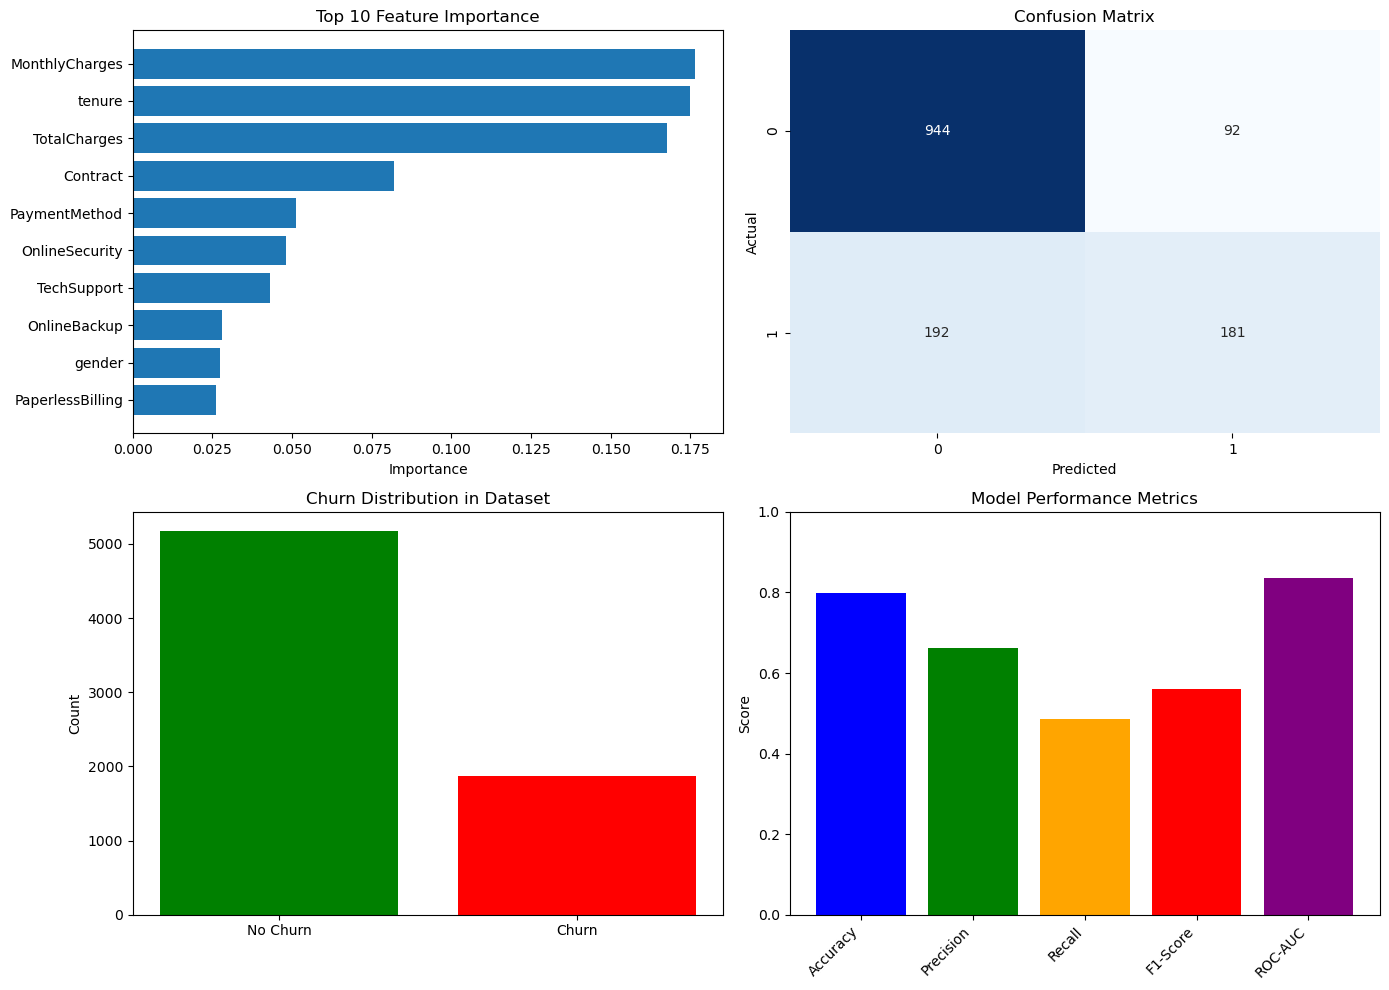

In [43]:
# Create a comprehensive visualization of the final dataset
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Feature Importance
ax1 = axes[0, 0]
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False).head(10)
ax1.barh(feature_importance_df['feature'], feature_importance_df['importance'])
ax1.set_xlabel('Importance')
ax1.set_title('Top 10 Feature Importance')
ax1.invert_yaxis()

# Plot 2: Confusion Matrix Heatmap
ax2 = axes[0, 1]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, cbar=False)
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.set_title('Confusion Matrix')

# Plot 3: Churn Distribution
ax3 = axes[1, 0]
churn_counts = df_encoded['Churn'].value_counts()
ax3.bar(['No Churn', 'Churn'], churn_counts.values, color=['green', 'red'])
ax3.set_ylabel('Count')
ax3.set_title('Churn Distribution in Dataset')

# Plot 4: Model Performance Metrics
ax4 = axes[1, 1]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
values = [accuracy, precision, recall, f1, roc_auc]
ax4.bar(metrics, values, color=['blue', 'green', 'orange', 'red', 'purple'])
ax4.set_ylabel('Score')
ax4.set_ylim([0, 1])
ax4.set_title('Model Performance Metrics')
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

#### Conclusion

The dataset has been successfully preprocessed by handling missing values and converting categorical variables into numerical form. The data is now ready for feature selection and model training.

## Task 3: Feature Selection

#### Objective

Relevant features influencing customer churn are selected to improve model performance and reduce unnecessary complexity.

In [26]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

feature_scores = pd.DataFrame({
    'feature': X.columns,
    'score': selector.scores_,
    'p_value': selector.pvalues_
}).sort_values(by='score', ascending=False).reset_index(drop=True)

print(feature_scores)
print("\nTop 10 selected features:", feature_scores['feature'].head(10).tolist())

             feature        score        p_value
0           Contract  1315.088872  3.666675e-264
1             tenure   997.268010  7.999058e-205
2     OnlineSecurity   643.162019  7.417493e-136
3        TechSupport   610.610024  2.351115e-129
4       OnlineBackup   279.877370   1.223404e-61
5     MonthlyCharges   273.463704   2.706646e-60
6   PaperlessBilling   268.985218   2.356554e-59
7   DeviceProtection   230.744618   2.651265e-51
8         Dependents   195.149314   9.140433e-44
9      SeniorCitizen   164.041424   3.839860e-37
10           Partner   163.060036   6.220731e-37
11     PaymentMethod    81.641664   2.075101e-19
12   InternetService    15.782320   7.177245e-05
13   StreamingMovies    10.447463   1.233835e-03
14     MultipleLines    10.201712   1.409286e-03
15       StreamingTV     9.434674   2.137335e-03
16      TotalCharges     1.476390   2.243809e-01
17      PhoneService     1.004266   3.163148e-01
18            gender     0.522257   4.699045e-01

Top 10 selected fea

#### Selected Features

The following features were selected because they have a significant influence on customer churn:

- Contract
- Tenure
- Online Security
- Tech Support
- Online Backup
- Monthly Charges
- Paperless Billing
- Device Protection
- Dependents
- Senior Citizen

These features capture customer demographics, subscription details, billing information, and service usage, all of which are important indicators of customer churn.

In [27]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [28]:
print(X)

      gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0          0              0        1           0       1             0   
1          1              0        0           0      34             1   
2          1              0        0           0       2             1   
3          1              0        0           0      45             0   
4          0              0        0           0       2             1   
...      ...            ...      ...         ...     ...           ...   
7038       1              0        1           1      24             1   
7039       0              0        1           1      72             1   
7040       0              0        1           1      11             0   
7041       1              1        1           0       4             1   
7042       1              0        0           0      66             1   

      MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0                 1                0     

In [24]:
print(y)

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64


#### Conclusion

The most relevant features were selected based on their relationship with customer churn and domain knowledge. These features are used as inputs for training the Random Forest classifier.

## Task 2: Train-Test Split

#### Objective

The dataset is divided into training and testing sets using an 80:20 ratio to evaluate the model on unseen data.

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (5634, 19)
Testing samples: (1409, 19)


#### Conclusion

The dataset has been successfully divided into training (80%) and testing (20%) sets, ensuring that the model is trained on one subset and evaluated on another.

## Task 4: Model Selection

#### Objective
The objective of this task is to select a suitable machine learning algorithm for predicting customer churn, which is a binary classification problem.

#### Algorithms Considered

The following binary classification algorithms were considered:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting

Each algorithm has different strengths depending on the dataset characteristics.

#### Selected Model: Random Forest Classifier

Random Forest was selected for this project because:

- Customer churn prediction is a binary classification problem.
- The dataset contains both categorical and numerical features.
- Random Forest can capture complex and non-linear relationships between customer attributes and churn.
- It is less prone to overfitting than a single Decision Tree.
- It performs well on structured tabular datasets.
- It provides feature importance, helping identify the factors that influence customer churn.
- It generally achieves higher predictive performance compared to simpler models.

In [30]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

#### Conclusion

Based on the characteristics of the Telco Customer Churn dataset, Random Forest was selected as the classification algorithm because it effectively handles mixed feature types, captures complex relationships among customer attributes, reduces overfitting, and provides feature importance for better interpretability.

## Task 5: Model Training

#### Objective

The selected machine learning model is trained using the training dataset. The chosen features are used as input variables, while the **Churn** column is used as the target variable.

In [33]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model training completed successfully.")

Model training completed successfully.


#### Conclusion

The selected machine learning model has been successfully trained using the training dataset. The chosen customer features were used as input variables, while the **Churn** column served as the target variable. The trained model is now ready for evaluation and prediction.

## Task 6: Model Evaluation

#### Objective

The performance of the trained Random Forest model is evaluated on the testing dataset using various classification metrics, including Accuracy, Precision, Recall, F1-score, and ROC-AUC. These metrics provide a comprehensive understanding of the model's predictive performance.

In [35]:
# Predict class labels
y_pred = model.predict(X_test)

# Predict probabilities for ROC-AUC
y_prob = model.predict_proba(X_test)[:, 1]

In [40]:
# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\nRecall Score: ",recall)
print("\nf1 Score: ",f1)
print("\nROC_AUC",roc_auc)

Accuracy: 0.7984

Confusion Matrix:
[[944  92]
 [192 181]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.49      0.56       373

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.71      1409
weighted avg       0.79      0.80      0.79      1409


Recall Score:  0.48525469168900803

f1 Score:  0.5603715170278638

ROC_AUC 0.8347881105924002


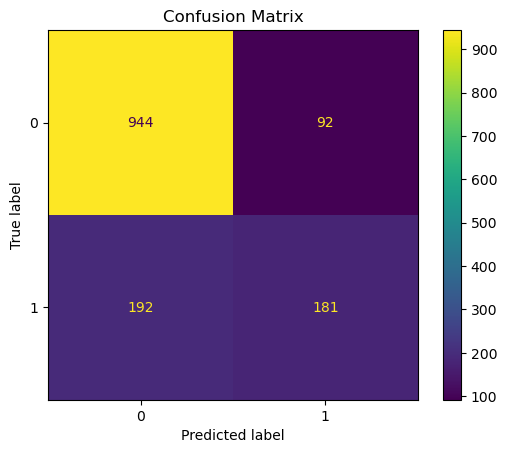

In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix")
plt.show()

#### Conclusion

The trained Random Forest model was evaluated using multiple performance metrics. Accuracy measures the overall correctness of predictions, while Precision and Recall assess the model's performance on the churn class. The F1-score provides a balance between Precision and Recall, and ROC-AUC measures the model's ability to distinguish between churn and non-churn customers. Together, these metrics offer a comprehensive evaluation of the model's effectiveness.